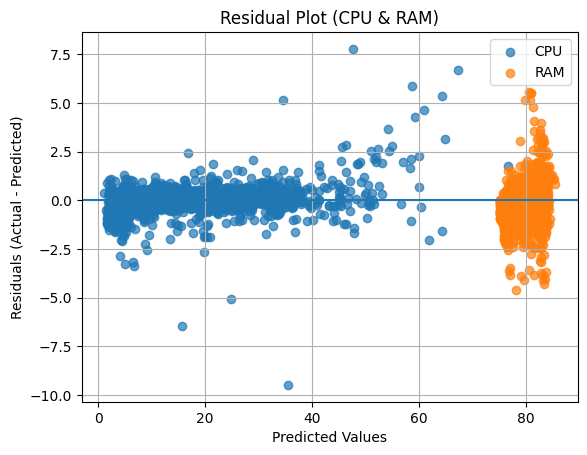


Feature Importance:

         Feature  Importance
4       cpu_lag1    0.547890
2     cpu_change    0.400683
5       ram_lag1    0.042748
1  ram_roll_mean    0.003734
0  cpu_roll_mean    0.002481
3     ram_change    0.002464


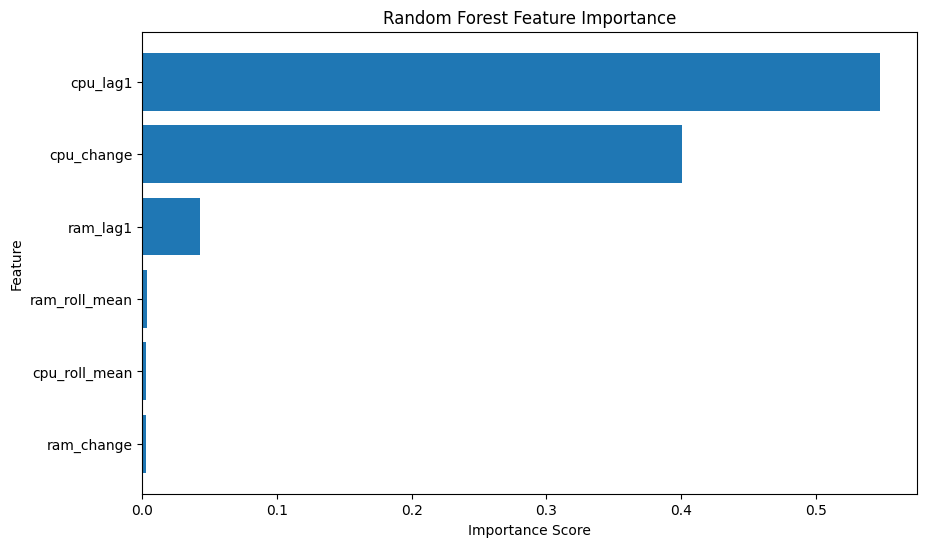

Random Forest Results
MSE: 0.25982129052185077
Train MSE:  0.04273644965653947
RMSE: 0.5097266821757036
R²: 0.965844076715318


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# 1 Load Train and Test Data
# -----------------------------
train_data = pd.read_csv("../data/train_data.csv")
test_data = pd.read_csv("../data/test_data.csv")

# -----------------------------
# 2 Define Target Variables
# -----------------------------
targets = ["cpu_percent", "ram_percent"]
useless_features = [
    "net_roll_mean",
    "net_change", 
    "net_lag1",
    "net_bytes_per_sec",
    "hour",
    "minute"
]

drop_cols = targets + useless_features
X_train = train_data.drop(columns=drop_cols)
X_test  = test_data.drop(columns=drop_cols)
y_train = train_data[targets]
y_test  = test_data[targets]
joblib.dump(X_train.columns, "../data/column.pkl")
# -----------------------------
# 3 Train Random Forest Model
# -----------------------------
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

#Model Dumping
joblib.dump(rf_model, "../data/model.pkl")

# -----------------------------
# 4 Predictions
# -----------------------------
y_pred = rf_model.predict(X_test)
x_pred = rf_model.predict(X_train)
residuals = np.abs(y_pred - y_test.values)
std_residuals = np.std(residuals, axis=0)
normalized_scores = np.mean(residuals / (std_residuals + 1e-6), axis=1)
mu = np.mean(normalized_scores)
sigma = np.std(normalized_scores)
threshold = mu + (3 * sigma)

#Threshold Dumping
joblib.dump(threshold, "../data/threshold.pkl")
joblib.dump(std_residuals, "../data/std_residuals.pkl")


# -----------------------------
# 5 Evaluation Metrics
# -----------------------------
mse = mean_squared_error(y_test, y_pred)
x_mse = mean_squared_error(y_train, x_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# -----------------------------
# 6 Combined Residual Plot
# -----------------------------

# CPU
cpu_actual = y_test["cpu_percent"].values
cpu_pred   = y_pred[:, 0]
cpu_residuals = cpu_actual - cpu_pred

# RAM
ram_actual = y_test["ram_percent"].values
ram_pred   = y_pred[:, 1]
ram_residuals = ram_actual - ram_pred

plt.figure()

# CPU points
plt.scatter(cpu_pred, cpu_residuals, label="CPU", alpha=0.7)

# RAM points
plt.scatter(ram_pred, ram_residuals, label="RAM", alpha=0.7)

# Zero line
plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (CPU & RAM)")
plt.legend()
plt.grid(True)

plt.show()

# -----------------------------
# 7 Actual vs Predicted Plot
# -----------------------------

# CPU
cpu_actual = y_test["cpu_percent"].values
cpu_pred   = y_pred[:, 0]

# RAM
ram_actual = y_test["ram_percent"].values
ram_pred   = y_pred[:, 1]

plt.figure()

# CPU points
plt.scatter(cpu_actual, cpu_pred, label="CPU", alpha=0.7)

# RAM points
plt.scatter(ram_actual, ram_pred, label="RAM", alpha=0.7)

# Perfect prediction line (y = x)
min_val = min(cpu_actual.min(), ram_actual.min())
max_val = max(cpu_actual.max(), ram_actual.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (CPU & RAM)")
plt.legend()
plt.grid(True)

plt.show()



# ----------------------------------
# 1 Get Feature Importance
# ----------------------------------
importance = rf_model.feature_importances_

# ----------------------------------
# 2 Create DataFrame
# ----------------------------------
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# ----------------------------------
# 3 Sort by Importance
# ----------------------------------
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# ----------------------------------
# 4 Print Important Features
# ----------------------------------
print("\nFeature Importance:\n")
print(feature_importance)

# ----------------------------------
# 5 Plot Feature Importance
# ----------------------------------
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()


print("Random Forest Results")
print("MSE:", mse)
print("Train MSE: ", x_mse)
print("RMSE:", rmse)
print("R²:", r2)